In [1]:
import kagglehub

# Download latest version
path = kagglehub.competition_download('classification-warm-up-competition')

print("Path to competition files:", path)

100%|██████████| 727k/727k [00:00<00:00, 1.20MB/s]

Extracting files...
Path to competition files: C:\Users\raian\.cache\kagglehub\competitions\classification-warm-up-competition


In [9]:
import pandas as pd
import numpy as np
train_df = pd.read_csv(path + '/train.csv')
test_df = pd.read_csv(path + '/test.csv')
train_df

,id,age,height(cm),weight(kg),waist(cm),eyesight(left),eyesight(right),hearing(left),hearing(right),systolic,...,HDL,LDL,hemoglobin,Urine protein,serum creatinine,AST,ALT,Gtp,dental caries,smoking
0,0,40.0,165.0,65.0,86.3,1.2,1.2,1.0,1.0,110.0,...,48.0,94.0,14.7,1.0,1.0,18.0,14.0,19.0,1.0,1.0
1,1,45.0,175.0,75.0,86.0,1.2,1.2,1.0,1.0,110.0,...,47.0,91.0,14.5,1.0,0.9,23.0,16.0,32.0,0.0,1.0
2,2,40.0,170.0,70.0,80.5,1.5,1.2,1.0,1.0,110.0,...,44.0,116.0,16.5,1.0,0.9,16.0,23.0,41.0,0.0,1.0
3,3,40.0,165.0,55.0,77.5,1.5,1.5,1.0,1.0,94.0,...,52.0,140.0,14.2,1.0,0.8,16.0,11.0,21.0,0.0,1.0
4,4,35.0,175.0,70.0,82.0,1.2,1.2,1.0,1.0,122.0,...,45.0,135.0,15.4,1.0,1.1,21.0,37.0,27.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14995,14995,30.0,170.0,75.0,81.0,1.2,0.9,1.0,1.0,120.0,...,42.0,142.0,15.6,1.0,0.9,21.0,21.0,23.0,0.0,0.0
14996,14996,40.0,170.0,60.0,75.9,1.5,1.5,1.0,1.0,108.0,...,54.0,122.0,15.5,1.0,0.8,26.0,29.0,56.0,1.0,1.0
14997,14997,25.0,170.0,85.0,94.5,1.2,1.2,1.0,1.0,131.0,...,45.0,131.0,15.2,1.0,1.0,23.0,20.0,31.0,0.0,1.0
14998,14998,45.0,170.0,80.0,89.0,1.0,1.0,1.0,1.0,131.0,...,47.0,132.0,14.9,1.0,1.0,25.0,25.0,24.0,0.0,1.0


<Axes: >

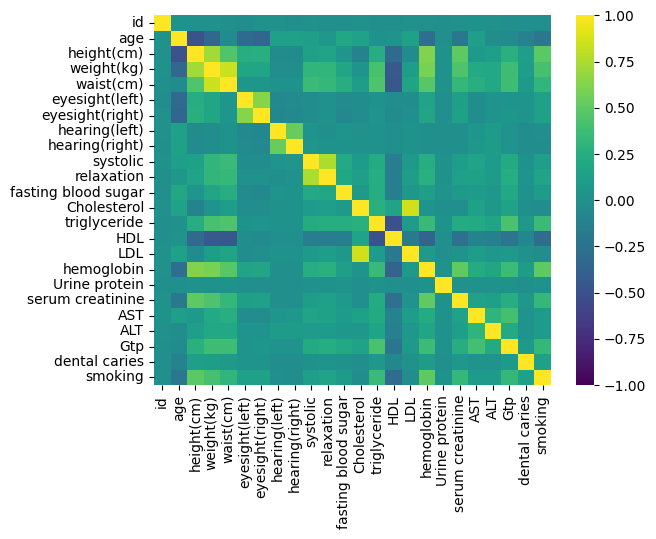

In [7]:
import seaborn as sns
sns.heatmap(train_df.corr(), vmin=-1, vmax=1, cmap='viridis')

In [44]:
import optuna
from xgboost import XGBClassifier

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score
scaler = StandardScaler()

x = train_df.drop(['smoking', 'id'], axis=1)
y = train_df['smoking']
x = scaler.fit_transform(x)

def objective(trial):
    n_estimators = trial.suggest_int('n_estimators', 100, 1500, log=True)
    max_depth = trial.suggest_int('max_depth', 2, 10)
    learning_rate = trial.suggest_float('learning_rate', 0.001, 0.1, log=True)
    model = XGBClassifier(n_estimators=n_estimators, max_depth=max_depth, learning_rate=learning_rate, eval_metric='logloss')
    return cross_val_score(model, x, y, scoring='roc_auc').mean()

study = optuna.create_study(direction='maximize')
study.optimize(objective, 50, show_progress_bar=True)

[I 2026-05-27 17:08:51,934] A new study created in memory with name: no-name-81b452bc-7aaa-4c79-a570-e9cf1ca74e2c


  0%|          | 0/50 [00:00<?, ?it/s]

[I 2026-05-27 17:08:52,519] Trial 0 finished with value: 0.8868318813332765 and parameters: {'n_estimators': 130, 'max_depth': 5, 'learning_rate': 0.07168101123116324}. Best is trial 0 with value: 0.8868318813332765.
[I 2026-05-27 17:08:53,593] Trial 1 finished with value: 0.8846324878612508 and parameters: {'n_estimators': 126, 'max_depth': 8, 'learning_rate': 0.048665501285584466}. Best is trial 0 with value: 0.8868318813332765.
[I 2026-05-27 17:08:55,041] Trial 2 finished with value: 0.8847666341116588 and parameters: {'n_estimators': 576, 'max_depth': 4, 'learning_rate': 0.010622942585998961}. Best is trial 0 with value: 0.8868318813332765.
[I 2026-05-27 17:08:55,669] Trial 3 finished with value: 0.8624834446097189 and parameters: {'n_estimators': 406, 'max_depth': 2, 'learning_rate': 0.0054855735188859694}. Best is trial 0 with value: 0.8868318813332765.
[I 2026-05-27 17:08:55,957] Trial 4 finished with value: 0.8596530848313897 and parameters: {'n_estimators': 158, 'max_depth': 2

In [45]:
study.best_params

{'n_estimators': 1225, 'max_depth': 2, 'learning_rate': 0.05083940614112139}

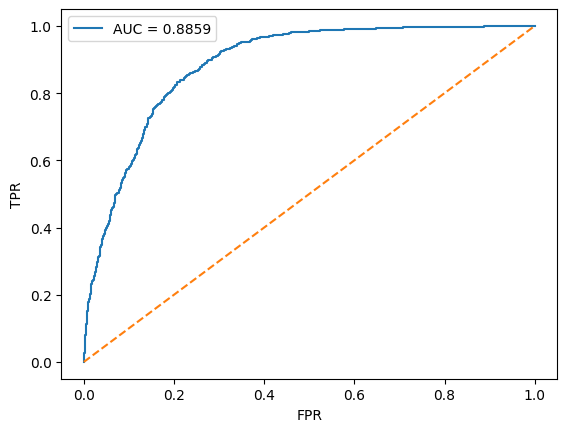

In [48]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve, roc_auc_score, auc
import matplotlib.pyplot as plt

model = XGBClassifier(**study.best_params)
x_train, x_val, y_train, y_val = train_test_split(x, y, test_size=0.2)
model.fit(x_train, y_train)
preds = model.predict_proba(x_val)[:, 1]
fpr, tpr, thresholds = roc_curve(y_val, preds)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.4f}')
plt.plot([0, 1], [0, 1], linestyle='--')

plt.xlabel('FPR')
plt.ylabel('TPR')
plt.legend()

In [49]:
from sklearn.metrics import accuracy_score
accuracy_score(y_val, preds > 0.5)

0.8093333333333333

Submission

In [52]:
model = XGBClassifier(**study.best_params)
model.fit(x, y)

ids = test_df['id']
test_x = test_df.drop('id', axis=1)
test_x = scaler.transform(test_x)
test_preds = model.predict_proba(test_x)[:, 1]
test_preds

array([0.01327778, 0.00935127, 0.08738317, ..., 0.00875931, 0.4277471 ,
       0.2134378 ], shape=(10000,), dtype=float32)

In [55]:
submission = pd.DataFrame({'id': ids, 'smoking': test_preds})
submission.to_csv('submission_1.csv', index=False)